In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os

print("OpenCV Version:", cv2.__version__)
print("TensorFlow Version:", tf.__version__)

OpenCV Version: 4.13.0
TensorFlow Version: 2.21.0


In [3]:
def preprocess_image(file_path):
    img = cv2.imread(file_path)
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clah_img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_img = clah_img.apply(gray_img)
    final_img = cv2.resize(enhanced_img, (64, 64))
    return final_img/255.0

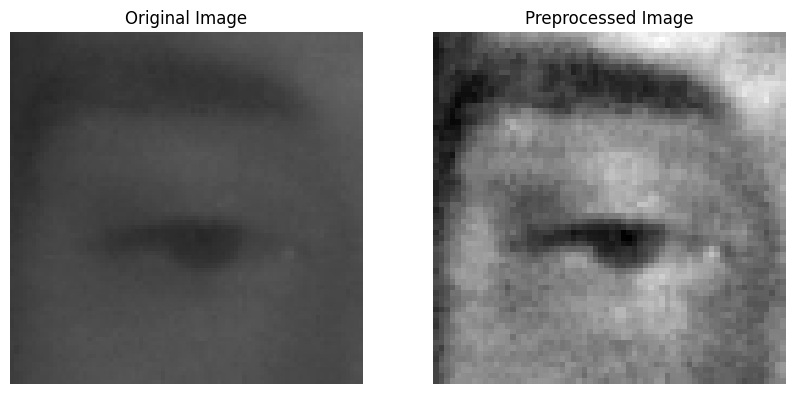

In [6]:
import matplotlib.pyplot as plt
sample_path = "data/train/awake/s0001_01842_0_0_1_0_0_01.png"
if os.path.exists(sample_path):
    img = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    processed_image = preprocess_image(sample_path)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed_image, cmap='gray')
    plt.title("Preprocessed Image")
    plt.axis('off')
    plt.show()

    plt.show()
else:
    print(f"sampel tidak ditemukan {sample_path}. cek dan coba lagi.")

In [10]:
def load_data(data_dir):
    X, y = [], []
    
    tags = {'awake': 1, 'sleepy': 0}
    for tag_name, label in tags.items():
        path_folder = os.path.join(data_dir, tag_name)
        if not os.path.exists(path_folder):
            print(f"folder {path_folder} tidak ditemukan.")
            continue
        for file_name in os.listdir(path_folder):
            if file_name.endswith('.png'):
                file_path=os.path.join(path_folder, file_name)
                try:
                    img = preprocess_image(file_path)
                    X.append(img)
                    y.append(label)
                except Exception as e:
                    print(f"gagal memproses {file_path}: {e}")
                    continue

    X = np.array(X).reshape(-1, 64, 64, 1)
    y = np.array(y)
    return X, y

X_train, y_train = load_data("data/train")
X_val, y_val = load_data("data/val")

print(f"Data latih: {X_train.shape}, {y_train.shape}")
print(f"Data validasi: {X_val.shape}, {y_val.shape}")


Data latih: (50937, 64, 64, 1), (50937,)
Data validasi: (16980, 64, 64, 1), (16980,)


In [ ]:
model = models.Sequential([
    #layer 1, kovolusi dan pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),

    #layer 2, filter untuk detail kelompok mata
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    #layer 3, pola spasial
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #layer 4, klasifikasi
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    #output
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,329 (794.25 KB)

 Trainable params: 203,329 (794.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("training model")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    shuffle=True
)

print("menyimpan model")


training model
Epoch 1/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - accuracy: 0.9268 - loss: 0.1866 - val_accuracy: 0.9622 - val_loss: 0.1056
Epoch 2/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.9680 - loss: 0.0894 - val_accuracy: 0.9746 - val_loss: 0.0690
Epoch 3/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - accuracy: 0.9763 - loss: 0.0658 - val_accuracy: 0.9788 - val_loss: 0.0582
Epoch 4/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.9813 - loss: 0.0519 - val_accuracy: 0.9845 - val_loss: 0.0460
Epoch 5/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9836 - loss: 0.0445 - val_accuracy: 0.9845 - val_loss: 0.0463
Epoch 6/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9866 - loss: 0.0378 - val_accuracy: 0.9832 - val_loss: 0.0478
Epoch 7/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9875 - loss: 0.0341 - val_accuracy: 0.9807 - val_loss: 0.0553
Epoch 8/10
796/796 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9888 - 

In [17]:
model.save("drowsiness_model.keras")

531/531 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9872 - loss: 0.0385
akurasi test: 0.9872, loss test: 0.0385


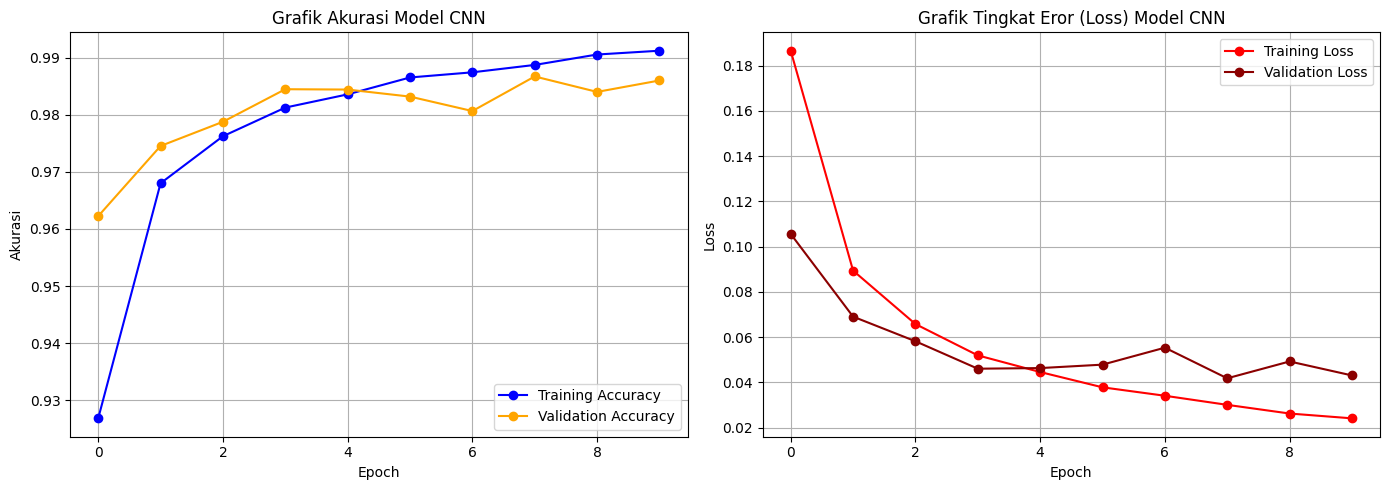

In [18]:
# testing model
X_test, y_test = load_data("data/test")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"akurasi test: {test_acc:.4f}, loss test: {test_loss:.4f}")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Grafik Akurasi Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkred', marker='o')
plt.title('Grafik Tingkat Eror (Loss) Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()